# Model Testing

In [8]:
import cv2
import numpy as np
import os
from pathlib import Path
import torch
from tqdm import tqdm
from ultralytics import YOLO
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, average_precision_score
from datetime import datetime
import psutil
import GPUtil
import time

2 Monitoring

In [9]:
class SystemMonitor:
    def __init__(self):
        self.cpu_usage = []
        self.memory_usage = []
        self.gpu_usage = []
        self.gpu_memory = []
        self.power_usage = []
        self.timestamps = []
        
    def sample(self):
        timestamp = time.time()
        cpu = psutil.cpu_percent(interval=None)
        memory = psutil.virtual_memory().percent
        
        gpus = GPUtil.getGPUs()
        if gpus:
            gpu = gpus[0]  # Assuming first GPU
            gpu_util = gpu.load * 100
            gpu_mem = gpu.memoryUtil * 100
            power = gpu.powerDraw if hasattr(gpu, 'powerDraw') else 0
        else:
            gpu_util = 0
            gpu_mem = 0
            power = 0
            
        self.timestamps.append(timestamp)
        self.cpu_usage.append(cpu)
        self.memory_usage.append(memory)
        self.gpu_usage.append(gpu_util)
        self.gpu_memory.append(gpu_mem)
        self.power_usage.append(power)

    def get_statistics(self):
        return {
            'cpu': {
                'avg': np.mean(self.cpu_usage),
                'min': np.min(self.cpu_usage),
                'max': np.max(self.cpu_usage)
            },
            'gpu': {
                'avg': np.mean(self.gpu_usage),
                'min': np.min(self.gpu_usage),
                'max': np.max(self.gpu_usage)
            },
            'power': {
                'avg': np.mean(self.power_usage),
                'total': np.sum(self.power_usage * (np.diff(self.timestamps + [time.time()]).mean() / 3600))  # kWh
            }
        }

1 Dataset Class

In [10]:
def KITTIDataset(image_dir, label_dir):
    class Dataset:
        def __init__(self, image_dir, label_dir):
            self.image_dir = Path(image_dir)
            self.label_dir = Path(label_dir)
            self.image_files = sorted([f for f in os.listdir(image_dir) if f.endswith('.png')])
        
        def parse_kitti_label(self, label_file):
            boxes = []
            classes = []
            
            with open(label_file, 'r') as f:
                for line in f:
                    parts = line.strip().split(' ')
                    if len(parts) < 15:
                        continue
                    
                    obj_class = parts[0]
                    bbox = [float(parts[4]), float(parts[5]), 
                           float(parts[6]), float(parts[7])]
                    
                    boxes.append(bbox)
                    classes.append(obj_class)
                    
            return np.array(boxes), classes
        
        def __len__(self):
            return len(self.image_files)
        
        def __getitem__(self, idx):
            img_file = self.image_files[idx]
            label_file = self.label_dir / f"{img_file.split('.')[0]}.txt"
            
            image = cv2.imread(str(self.image_dir / img_file))
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            
            boxes, classes = self.parse_kitti_label(label_file)
            
            return {
                'image': image,
                'boxes': boxes,
                'classes': classes,
                'image_file': img_file
            }
    
    return Dataset(image_dir, label_dir)


1 IoU Calculation

In [11]:
def calculate_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_area = max(0, x2 - x1) * max(0, y2 - y1)
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    iou = inter_area / (box1_area + box2_area - inter_area + 1e-6)
    return iou

2 mAP Calculation

In [12]:
def calculate_map(matches, confidences, recall_thresholds=np.linspace(0, 1, 11)):
    """Calculate mean Average Precision"""
    if len(matches) == 0 or len(confidences) == 0:
        return 0.0
        
    precision, recall, _ = precision_recall_curve(matches, confidences)
    # Interpolate precision at standard recall levels
    map_score = 0
    for t in recall_thresholds:
        mask = recall >= t
        if mask.any():
            map_score += np.max(precision[mask])
    return map_score / len(recall_thresholds)


1 Model Evaluation

In [13]:
def evaluate_model(model, dataset, iou_threshold=0.4,conf_threshold=0.2):
    true_positives, false_positives, false_negatives = 0, 0, 0
    matches = []
    confidences = []

    for data in tqdm(dataset, desc="Evaluating Model"):
        image = data['image']
        gt_boxes = data['boxes']
        
        results = model.predict(image, verbose=False)
        
        pred_boxes = []
        pred_confs = []
        
        for result in results:
            for box, conf in zip(result.boxes.xyxy, result.boxes.conf):
                if conf >= conf_threshold:
                    pred_boxes.append(box.cpu().numpy())
                    pred_confs.append(conf.item())
        
        gt_matched = np.zeros(len(gt_boxes), dtype=bool)
        
        for pred_box, conf in zip(pred_boxes, pred_confs):
            best_iou = 0
            best_gt_idx = -1
            
            for i, gt_box in enumerate(gt_boxes):
                iou = calculate_iou(pred_box, gt_box)
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = i
            
            if best_iou >= iou_threshold and not gt_matched[best_gt_idx]:
                true_positives += 1
                gt_matched[best_gt_idx] = True
                matches.append(1)
            else:
                false_positives += 1
                matches.append(0)
            
            confidences.append(conf)
        
        false_negatives += np.sum(~gt_matched)

    precision = true_positives / (true_positives + false_positives + 1e-6)
    recall = true_positives / (true_positives + false_negatives + 1e-6)
    f1_score = 2 * (precision * recall) / (precision + recall + 1e-6)

    return {
        "metrics": {
            "precision": precision,
            "recall": recall,
            "f1_score": f1_score
        },
        "true_positives": true_positives,
        "false_positives": false_positives,
        "false_negatives": false_negatives,
        "matches": matches,
        "confidences": confidences
    }


2 Model Evaluation

def evaluate_model(model, dataset, iou_threshold=0.4, conf_threshold=0.2):
    system_monitor = SystemMonitor()
    true_positives, false_positives, false_negatives = 0, 0, 0
    matches = []
    confidences = []
    processing_times = []
    
    for data in tqdm(dataset, desc="Evaluating Model"):
        start_time = time.time()
        system_monitor.sample()
        
        image = data['image']
        gt_boxes = data['boxes']
        results = model.predict(image, verbose=False)
        
        # Record processing time
        processing_times.append(time.time() - start_time)
        
        pred_boxes = []
        pred_confs = []
        for result in results:
            for box, conf in zip(result.boxes.xyxy, result.boxes.conf):
                if conf >= conf_threshold:
                    pred_boxes.append(box.cpu().numpy())
                    pred_confs.append(conf.item())
                    
        # [Previous matching logic remains the same]
        gt_matched = np.zeros(len(gt_boxes), dtype=bool)
        for pred_box, conf in zip(pred_boxes, pred_confs):
            best_iou = 0
            best_gt_idx = -1
            for i, gt_box in enumerate(gt_boxes):
                iou = calculate_iou(pred_box, gt_box)
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = i
            
            if best_iou >= iou_threshold and not gt_matched[best_gt_idx]:
                true_positives += 1
                gt_matched[best_gt_idx] = True
                matches.append(1)
            else:
                false_positives += 1
                matches.append(0)
            confidences.append(conf)
            
        false_negatives += np.sum(~gt_matched)

    # Calculate metrics
    precision = true_positives / (true_positives + false_positives + 1e-6)
    recall = true_positives / (true_positives + false_negatives + 1e-6)
    f1_score = 2 * (precision * recall) / (precision + recall + 1e-6)
    map_score = calculate_map(matches, confidences)
    fps = 1.0 / np.mean(processing_times)
    
    system_stats = system_monitor.get_statistics()
    
    return {
        "metrics": {
            "precision": precision,
            "recall": recall,
            "f1_score": f1_score,
            "mAP": map_score,
            "fps": fps
        },
        "true_positives": true_positives,
        "false_positives": false_positives,
        "false_negatives": false_negatives,
        "matches": matches,
        "confidences": confidences,
        "system_metrics": {
            "cpu_usage": system_monitor.cpu_usage,
            "gpu_usage": system_monitor.gpu_usage,
            "power_usage": system_monitor.power_usage,
            "timestamps": system_monitor.timestamps,
            "stats": system_stats
        }
    }


1 Plot Metrix

In [14]:
def plot_metrics(results, model_name):
    """Plot various performance metrics"""
    plt.style.use('seaborn')
    fig = plt.figure(figsize=(15, 10))
    
    # Add timestamp and model name as figure suptitle
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    plt.suptitle(f'Model: {model_name}\nTimestamp: {timestamp}', y=1.02)
    
    # 1. Basic Metrics Bar Plot
    plt.subplot(2, 2, 1)
    metrics = results['metrics']
    names = list(metrics.keys())
    values = list(metrics.values())
    plt.bar(names, values)
    plt.title('Performance Metrics')
    plt.ylim(0, 1)
    for i, v in enumerate(values):
        plt.text(i, v + 0.01, f'{v:.3f}', ha='center')

    # 2. Precision-Recall Curve
    plt.subplot(2, 2, 2)
    matches = np.array(results['matches'])
    confidences = np.array(results['confidences'])
    if len(matches) > 0 and len(confidences) > 0:
        precision, recall, _ = precision_recall_curve(matches, confidences)
        plt.plot(recall, precision)
        plt.fill_between(recall, precision, alpha=0.2)
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title(f'Precision-Recall Curve\nAP: {average_precision_score(matches, confidences):.3f}')

    # 3. Confusion Matrix Heatmap
    plt.subplot(2, 2, 3)
    conf_matrix = np.array([
        [results['true_positives'], results['false_positives']],
        [results['false_negatives'], 0]  # We don't have true negatives
    ])
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Positive', 'Negative'],
                yticklabels=['Positive', 'Negative'])
    plt.title('Confusion Matrix')
    
    # 4. Additional Information
    plt.subplot(2, 2, 4)
    plt.axis('off')
    info_text = (
        f"Model Performance Summary:\n\n"
        f"Total Predictions: {len(results['matches'])}\n"
        f"True Positives: {results['true_positives']}\n"
        f"False Positives: {results['false_positives']}\n"
        f"False Negatives: {results['false_negatives']}\n\n"
        f"Precision: {results['metrics']['precision']:.4f}\n"
        f"Recall: {results['metrics']['recall']:.4f}\n"
        f"F1 Score: {results['metrics']['f1_score']:.4f}\n"
    )
    plt.text(0.1, 0.9, info_text, fontsize=10, verticalalignment='top')
    
    plt.tight_layout()
    return fig

2 plot metrics

In [15]:
def plot_metrics(results, model_name):
    plt.style.use('seaborn')
    fig = plt.figure(figsize=(20, 15))
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    plt.suptitle(f'Model: {model_name}\nTimestamp: {timestamp}', y=1.02)
    
    # 1. Basic Metrics Bar Plot
    plt.subplot(3, 2, 1)
    metrics = results['metrics']
    names = list(metrics.keys())
    values = list(metrics.values())
    plt.bar(names, values)
    plt.title('Performance Metrics')
    plt.xticks(rotation=45)
    for i, v in enumerate(values):
        plt.text(i, v + 0.01, f'{v:.3f}', ha='center')
    
    # 2. Precision-Recall Curve
    plt.subplot(3, 2, 2)
    matches = np.array(results['matches'])
    confidences = np.array(results['confidences'])
    if len(matches) > 0 and len(confidences) > 0:
        precision, recall, _ = precision_recall_curve(matches, confidences)
        plt.plot(recall, precision)
        plt.fill_between(recall, precision, alpha=0.2)
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title(f'Precision-Recall Curve\nmAP: {results["metrics"]["mAP"]:.3f}')
    
    # 3. System Resource Usage Over Time
    plt.subplot(3, 2, 3)
    timestamps = np.array(results['system_metrics']['timestamps'])
    timestamps = timestamps - timestamps[0]  # Relative time
    plt.plot(timestamps, results['system_metrics']['cpu_usage'], label='CPU')
    plt.plot(timestamps, results['system_metrics']['gpu_usage'], label='GPU')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Utilization (%)')
    plt.title('Resource Utilization')
    plt.legend()
    
    # 4. Power Usage Over Time
    plt.subplot(3, 2, 4)
    plt.plot(timestamps, results['system_metrics']['power_usage'])
    plt.xlabel('Time (seconds)')
    plt.ylabel('Power (W)')
    plt.title('Power Consumption')
    
    # 5. Confusion Matrix
    plt.subplot(3, 2, 5)
    conf_matrix = np.array([
        [results['true_positives'], results['false_positives']],
        [results['false_negatives'], 0]
    ])
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Positive', 'Negative'],
                yticklabels=['Positive', 'Negative'])
    plt.title('Confusion Matrix')
    
    # 6. System Statistics
    plt.subplot(3, 2, 6)
    plt.axis('off')
    stats = results['system_metrics']['stats']
    info_text = (
        f"System Performance Summary:\n\n"
        f"CPU Utilization:\n"
        f"  Average: {stats['cpu']['avg']:.1f}%\n"
        f"  Min: {stats['cpu']['min']:.1f}%\n"
        f"  Max: {stats['cpu']['max']:.1f}%\n\n"
        f"GPU Utilization:\n"
        f"  Average: {stats['gpu']['avg']:.1f}%\n"
        f"  Min: {stats['gpu']['min']:.1f}%\n"
        f"  Max: {stats['gpu']['max']:.1f}%\n\n"
        f"Power Consumption:\n"
        f"  Average: {stats['power']['avg']:.1f}W\n"
        f"  Total Energy: {stats['power']['total']:.2f}kWh\n\n"
        f"Processing Speed:\n"
        f"  Frames per second: {results['metrics']['fps']:.2f}"
    )
    plt.text(0.1, 0.9, info_text, fontsize=10, verticalalignment='top')
    
    plt.tight_layout()
    return fig

Load Model

In [16]:
model_path = "./Models/yolo11n.pt"

Main Execution


Starting evaluation...


Evaluating Model: 100%|██████████| 7481/7481 [02:20<00:00, 53.25it/s]
/tmp/ipykernel_23520/3148300000.py:2: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')



Evaluation Results:
Precision: 0.7130
Recall: 0.4732
F1 Score: 0.5688


KeyError: 'mAP'

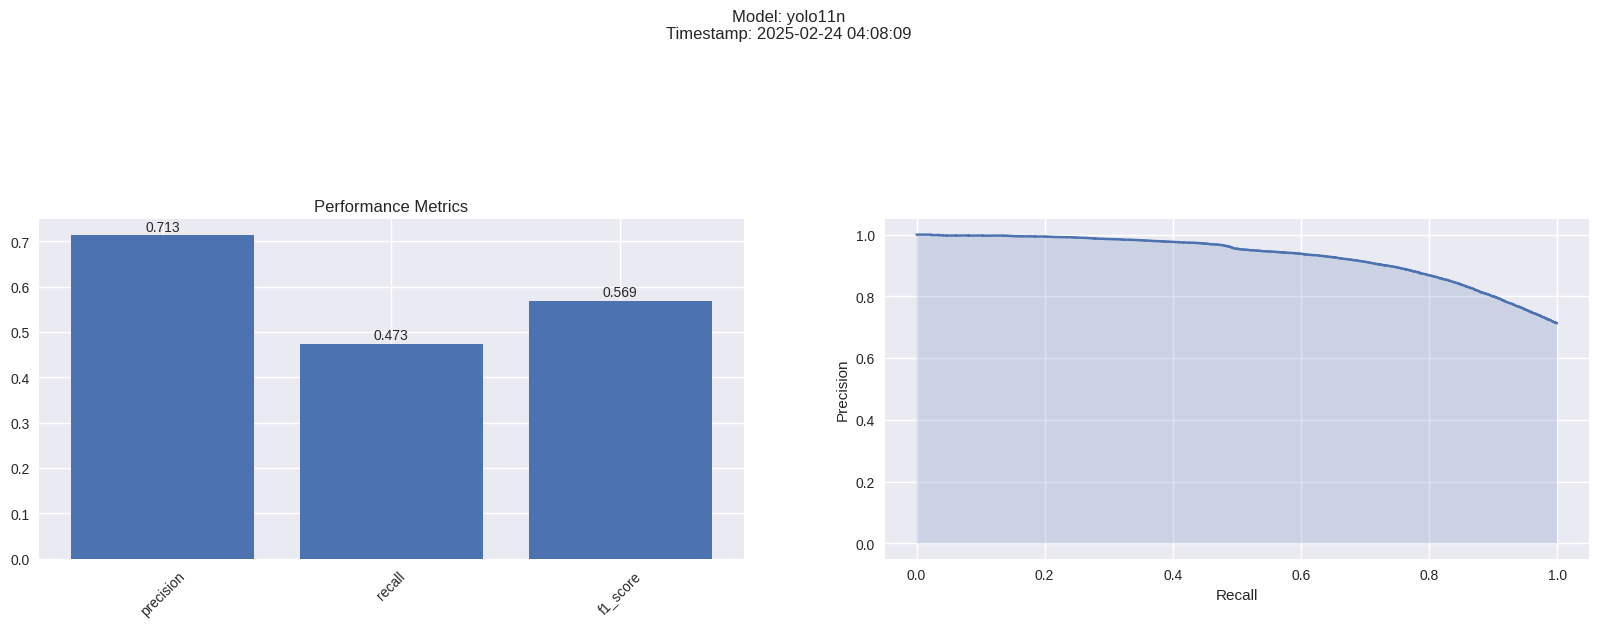

In [17]:
if __name__ == "__main__":
    image_dir = "./Dataset/Kitty_DataSet/image/training/image_2"
    label_dir = "./Dataset/Kitty_DataSet/label/training/label_2"
    performance_dir = "./Performance"
    
    os.makedirs(performance_dir, exist_ok=True)
    
    dataset = KITTIDataset(image_dir, label_dir)
    
    model = YOLO(model_path)
    model_name = Path(model_path).stem
    
    print("\nStarting evaluation...")
    results = evaluate_model(model, dataset)
    
    print("\nEvaluation Results:")
    print(f"Precision: {results['metrics']['precision']:.4f}")
    print(f"Recall: {results['metrics']['recall']:.4f}")
    print(f"F1 Score: {results['metrics']['f1_score']:.4f}")
    
   # Plot metrics and save with timestamp
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    metrics_fig = plot_metrics(results, model_name)
    
    # Save figure as SVG
    save_path = os.path.join(performance_dir, f"Performance_{timestamp}.svg")
    metrics_fig.savefig(save_path, format='svg', bbox_inches='tight', dpi=300)
    print(f"\nPerformance metrics saved to: {save_path}")

     # Display plot
    plt.show()
